In [1]:
import re
from collections import defaultdict
path_letencies = []
K = 3
N = 50
# for K in [3, 5, 10]:
for K in [3]:
	# filename = [f"test_data/N={N}_1/random_K={K}.txt", f"test_data/N={N}_1/1shortest_K={K}.txt"]
	filename = [f"test_data/N=50_K=3.txt", "test_data/N=50_K=3_latency=0.txt"]
	for i in range(2):
		with open(filename[i]) as f:
			data = f.read()
		# Regular expression to extract time and endpoint information
		pattern = re.compile(r'当前时间（毫秒精度）: (\d+), Endpoint: hostname: "(.*?)"\nport: (\d+)')

		# Dictionary to store times by endpoint
		time_by_endpoint = defaultdict(list)

		# Extract matches and organize by endpoint
		for match in pattern.finditer(data):
			time, hostname, port = match.groups()
			endpoint = f"{hostname}:{port}"
			time_by_endpoint[endpoint].append(int(time))

		# Print the results
		# for endpoint, times in time_by_endpoint.items():
		#     print(f"Endpoint: {endpoint}")
		#     print(f"Times: {times}\n")

		path_latency = []
		for endpoint, times in time_by_endpoint.items():
			path_latency.append(times[0] - time_by_endpoint['127.0.0.7:1234'][0])
		path_letencies.append(path_latency)


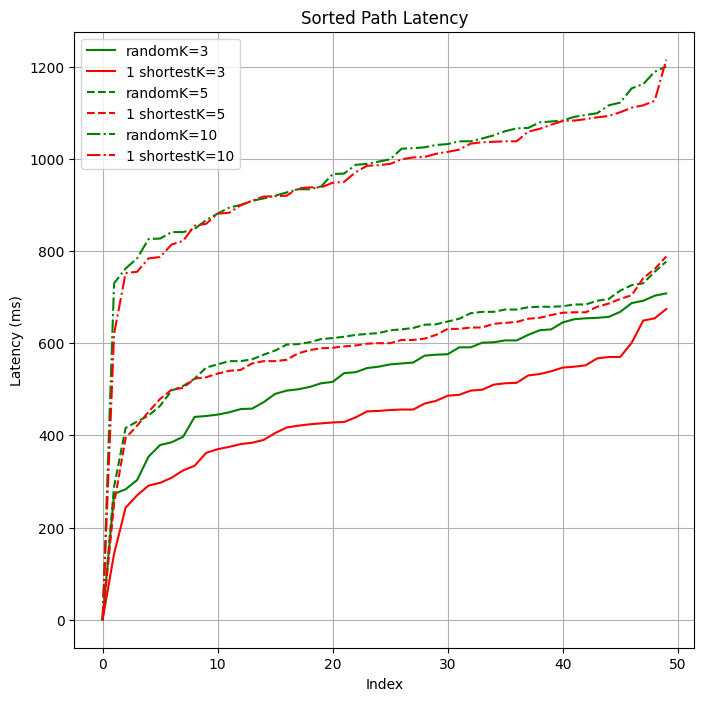

In [99]:
import matplotlib.pyplot as plt

# Example list of path latencies
# path_latency = [15, 23, 7, 18, 12, 35, 9, 21]

# Sort the list



# Plot the sorted list
fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
labels = ['random', '1 shortest']
colors = ['g', 'r']
linestyles = ['-', '--', '-.']
cnt = 0
for k in [3, 5, 10]:
	for i in range(2):
		path_latency_sorted = sorted(path_letencies[cnt])
		ax.plot(path_latency_sorted, linestyle=linestyles[cnt // 2], label=labels[i]+f'K={k}', color=colors[i])
		cnt += 1
ax.set_title('Sorted Path Latency')
ax.set_xlabel('Index')
ax.set_ylabel('Latency (ms)')
ax.legend()
ax.grid(True)
plt.show()

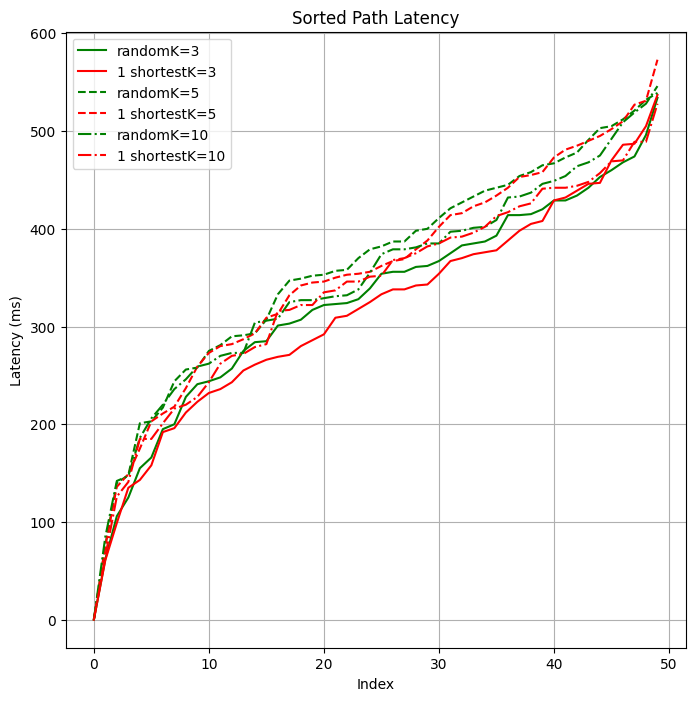

In [18]:
import matplotlib.pyplot as plt

# Example list of path latencies
# path_latency = [15, 23, 7, 18, 12, 35, 9, 21]

# Sort the list



# Plot the sorted list
fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
labels = ['random', '1 shortest']
colors = ['g', 'r']
linestyles = ['-', '--', '-.']
cnt = 0
# for k in [3, 5, 10]:
for k in [3, 5, 10]:
	for i in range(2):
		path_latency_sorted = sorted(path_letencies[cnt])
		ax.plot(path_latency_sorted, linestyle=linestyles[cnt // 2], label=labels[i]+f'K={k}', color=colors[i])
		cnt += 1
ax.set_title('Sorted Path Latency')
ax.set_xlabel('Index')
ax.set_ylabel('Latency (ms)')
ax.legend()
ax.grid(True)
plt.show()
fig.savefig('2.png')

[0, 96, 108, 108, 189, 195, 196, 217, 224, 225, 226, 227, 231, 292, 298, 301, 301, 301, 306, 307, 311, 315, 322, 323, 330, 332, 333, 334, 341, 341, 345, 348, 393, 399, 404, 407, 407, 413, 414, 415, 422, 422, 429, 436, 439, 441, 441, 500, 512, 529]
[0, 93, 95, 108, 165, 189, 193, 195, 197, 198, 224, 224, 230, 246, 267, 281, 286, 287, 291, 297, 303, 306, 307, 310, 311, 318, 326, 333, 333, 340, 340, 352, 356, 358, 372, 375, 385, 390, 392, 398, 403, 413, 430, 432, 436, 440, 447, 449, 461, 479]


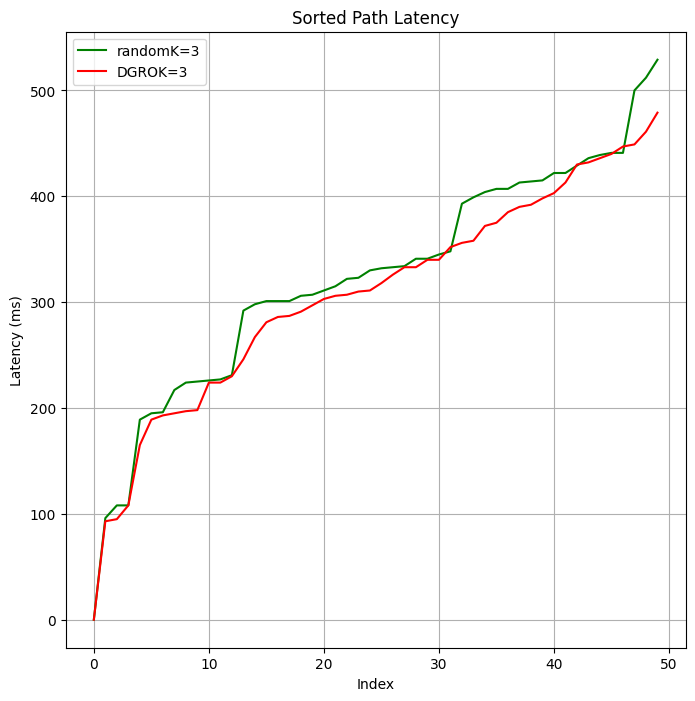

In [ ]:
import matplotlib.pyplot as plt

# Plot the sorted list
fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
labels = ['random', 'DGRO']
colors = ['g', 'r']
linestyles = ['-', '--', '-.']
cnt = 0
# for k in [3, 5, 10]:
for k in [3]:
	for i in range(2):
		path_latency_sorted = sorted(path_letencies[cnt])
		print(path_latency_sorted)
		ax.plot(path_latency_sorted, linestyle=linestyles[cnt // 2], label=labels[i]+f'_FanOut={k}_N=50', color=colors[i])
		cnt += 1
ax.set_title('Sorted Path Latency')
ax.set_xlabel('Index')
ax.set_ylabel('Latency (ms)')
ax.legend()
ax.grid(True)
plt.show()
fig.savefig('2.png')